## NeRF Implementation
In this Notebook we do the following:
* load a small training set $\mathcal{T}$
* train NeRF on this training set
* generate a new training net $\hat{\mathcal{T}}$ using NeRF 


In [1]:
# !git clone https://github.com/uprestel/AutoNeRF.git
import AutoNeRF.models.nerf as nerf
import AutoNeRF.data.data
from AutoNeRF.data.data import AutoNeRF_Dataset
from AutoNeRF.util.transforms import random_rotation, look_at_rotation

import torchvision
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Set dataset dependent parameters
dataset_name = "chair"

# Set flag to differentiate between training from scratch and training from trained model
training_from_scratch = False

## Load small dataset $\mathcal{T}$
We load the small dataset we train NeRF on, then we display a chosen test- image. Note that this test-image is not used during training.
Our dataset has the following properties
* our scenes can be contained in a ball $B_r(0)$ with $r=2$
* we only sample from our rays within this ball


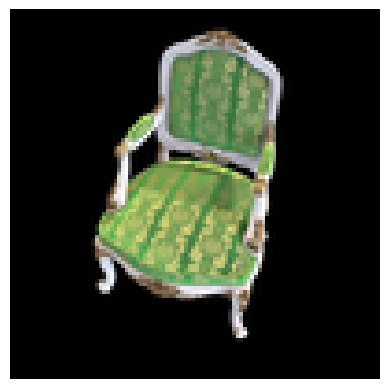

In [3]:
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set the random seeds for reproducibility
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

dataset = AutoNeRF_Dataset(f"../data/{dataset_name}.npz")

# For all our scenes our object is enclosed in a ball at the origin with radius 2
SCENE_RADIUS = 2

def show(image, permutation=(0,1,2)):
    grid_img = torchvision.utils.make_grid(image, nrow=5)
    plt.imshow(grid_img.permute(permutation))
    plt.axis('off')
    plt.show()


def get_thresholds(r):
    diff = r - SCENE_RADIUS
    tn = diff
    tf = diff + 2*SCENE_RADIUS

    return tn, tf



images = torch.from_numpy(dataset.images).to(device)
focal_length = torch.from_numpy(dataset.focal_length).to(device)
poses = torch.from_numpy(dataset.poses).to(device)

height, width = images.shape[1:3]



testimg = images[99, ..., :3]
testpose = poses[99]


translation = poses[:, :3,3]
center = torch.zeros(3).to(device)
diff = center - translation

n = torch.norm(diff, p=2, dim=1)
radius = torch.mean(n)

show(images[99].cpu())

In [4]:
# check the center of the dataset
print("Center of dataset (mean translation):", poses[:, :3, 3].mean(dim=0))


Center of dataset (mean translation): tensor([-0.1015,  0.4164,  2.3929], device='cuda:0')


#### Display the first 10 images form the dataset

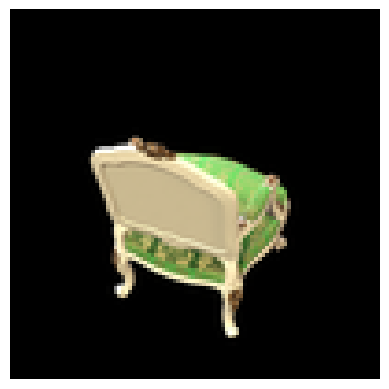

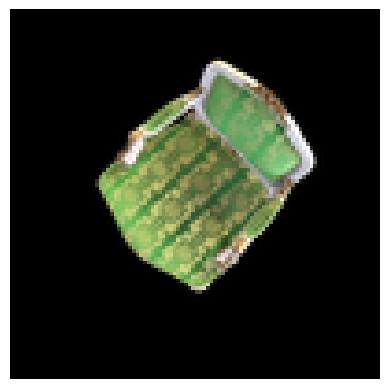

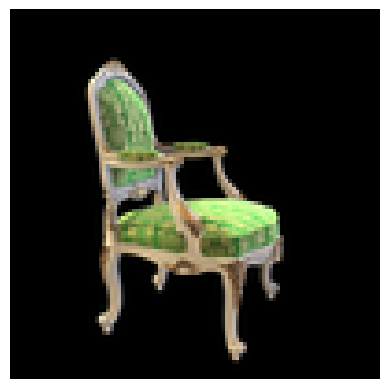

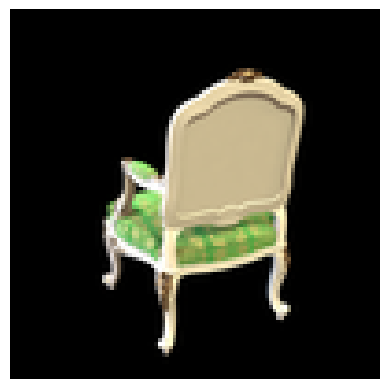

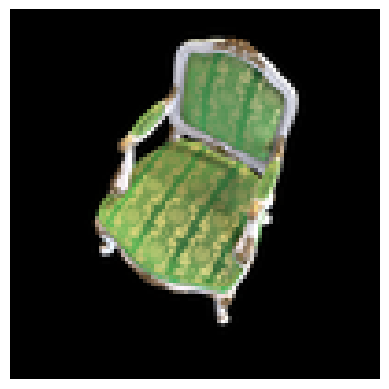

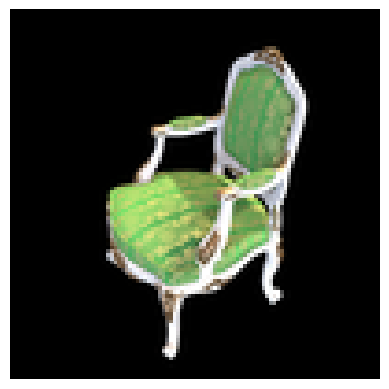

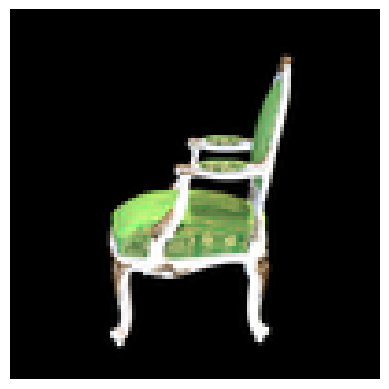

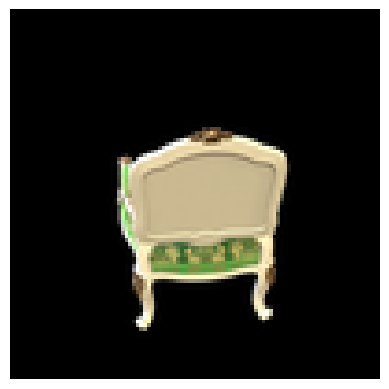

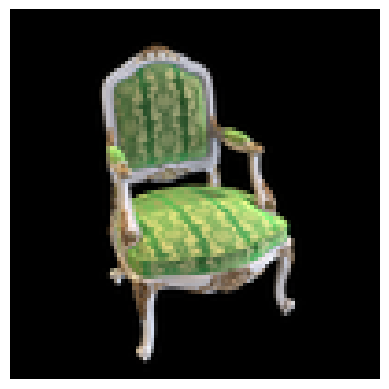

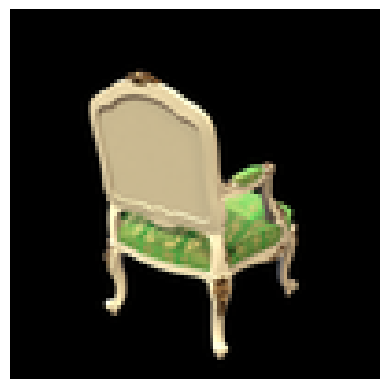

In [5]:
for i in range(0, 10):
    show(images[i].cpu())

## Set parameters

In [6]:
# ------------------------ PARAMETERS ------------------------
# Number of functions used in the positional encoding (Be sure to update the 
# model if this number changes).
num_encoding_functions = 6
# Specify encoding function.
encode = lambda x: nerf.positional_encoding(x, num_encoding_functions=num_encoding_functions)
# Number of depth samples along each ray.
depth_samples_per_ray = 228


# Optimizer parameters
lr = 5e-3
#num_iters = 100000
epochs = 100
display_every = 100  # Number of iters after which stats are displayed

# Define the model. We find that initializing NeRF with an already trained model speeds
# the training process for a new scene!
if not training_from_scratch:
    # Training from a trained model
    model = nerf.TinyNerfModel().to(device)
    model.load_state_dict(torch.load("../model_checkpoints/nerf_chair_v0.pt"))
    # model.eval()
elif training_from_scratch:
    # Training from scratch
    model = nerf.TinyNerfModel(num_encoding_functions=num_encoding_functions)
    model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []

near_thresh, far_thresh = get_thresholds(radius)
#near_thresh = 2.
#far_thresh = 6.


## Train NeRF


In [ ]:
# ------------------------ TRAINING LOOP ------------------------
model.train()

if model.training:
    for epoch in range(epochs):
        for i, dat in enumerate(dataset):
            target_image, target_pose = dat
            target_image = torch.Tensor(target_image).to(device)
            target_pose = torch.Tensor(target_pose).to(device)
            rgb_predicted = nerf.run_one_iter_of_tinynerf(model, height, width, focal_length,
                                                    target_pose, near_thresh,
                                                    far_thresh, depth_samples_per_ray,
                                                    encode, nerf.get_minibatches)
            loss = torch.nn.functional.mse_loss(rgb_predicted, target_image)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            losses.append(loss.item())
            
        # Now we compare the prediction of NeRF at the test-pose vs. the ground truth
        rgb_predicted = nerf.nerf_prediction(model, height, width, focal_length,
                                                testpose, near_thresh,
                                                far_thresh, depth_samples_per_ray,
                                                encode, nerf.get_minibatches)
        plt.figure(figsize=(10, 4))
        plt.subplot(131)
        plt.imshow(rgb_predicted.detach().cpu().numpy())
        plt.title(f"Prediction at epoch {epoch}")
        plt.subplot(132)
        plt.imshow(testimg.detach().cpu().numpy())
        plt.title("Ground truth")
        plt.subplot(133)
        plt.plot(losses)
        plt.title("Loss")
        
        plt.show()

        # Save the model every 20 epoch
        if (epoch + 1) % 20 == 0:
            torch.save(model.state_dict(), f"../model_temp_checkpoints/nerf_{dataset_name}_{epoch + 1}.pt")



## Save / load the model

In [ ]:
torch.save(model.state_dict(), f"../model_checkpoints/nerf_{dataset_name}.pt")

In [9]:
model = nerf.TinyNerfModel().to(device)
model.load_state_dict(torch.load(f"../model_checkpoints/nerf_{dataset_name}.pt"))
model.eval()

TinyNerfModel(
  (layer1): Linear(in_features=39, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (layer4): Linear(in_features=64, out_features=32, bias=True)
  (layer5): Linear(in_features=32, out_features=4, bias=True)
)

## Render novel views using a trained NeRF

### sample new views
* our radius (how far we are away we position the camera ) is sampled from $\mathcal{U}[r-1, r+1]$


/home/jimmy/codes/nerf-image-generation/.venv/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


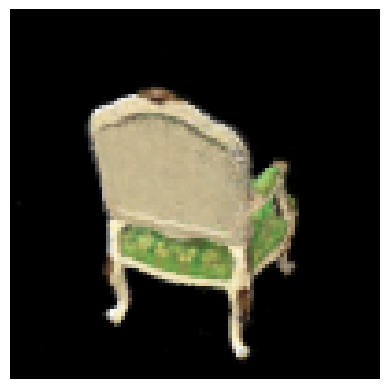

In [10]:
UP = torch.tensor([0.,0.,1.]).unsqueeze(dim=0).to(device)

def get_new_pose(center, radius):
    """
    generates a new pose / perspective for the NeRF model
    """

    rot = random_rotation().to(device)
    unit_x = torch.tensor([1.,0.,0.]).to(device)
    new_t = center + radius*(rot @ unit_x)

    new_t[2] = torch.abs(new_t[2])


    cam_rot = look_at_rotation(at=new_t.unsqueeze(dim=0), 
                               camera_position=center.unsqueeze(dim=0),up=UP) #tform_cam2world[0, :3, :3]#

    #cam_rot = torch.transpose(cam_rot, 1,2)
    transform = torch.zeros((4,4))#.to(device)
    
    transform[:3, :3] = cam_rot
    transform[:3, 3] = new_t
    transform[3, 3] = 1
    #print(look_at_rotation(center))
    return transform


depth_samples_per_ray = 240

r = torch.tensor(np.random.uniform(radius.item()-1, radius.item()+1)).to(device)
near_thresh, fat_thresh = get_thresholds(r)

new_pose = get_new_pose(center, r).to(device)
predicted = nerf.nerf_prediction(model, height, width, focal_length, new_pose,
                             near_thresh, far_thresh, depth_samples_per_ray,
                             encode, nerf.get_minibatches)

show(predicted.cpu())

## Render new dataset

To successfully train our generative model, we generate a temporary dataset $\hat{\mathcal{T}}$. 

In [ ]:
num_encoding_functions = 6
encode = lambda x: nerf.positional_encoding(x, num_encoding_functions=num_encoding_functions)
depth_samples_per_ray = 240


poses = []
images = []
n_images = 30000
n_dataset = 10000

path = f"../generated_datasets/temp_dataset_{dataset_name}_new.pt"
dataset = AutoNeRF_Dataset()

for i in range(n_images):

    r = torch.tensor(np.random.uniform(radius.item()-1, radius.item()+1)).to(device)
    near_thresh, fat_thresh = get_thresholds(r)
    new_pose = get_new_pose(center, r).to(device)
    predicted = nerf.nerf_prediction(model, height, width, focal_length, new_pose,
                                near_thresh, far_thresh, depth_samples_per_ray,
                                encode, nerf.get_minibatches).cpu().detach().numpy()
    poses.append(new_pose.cpu().detach().numpy())
    images.append(predicted)
    

    del predicted
    del new_pose
    if i%1000==0:
        print("at iteration ", i)
        
    if (i+1) % n_dataset == 0 and i>0:
        
        # new now save the temporary dataset, since we have reached max capacity
        pth = os.path.splitext(path)
        filename = pth[-2] + str((i+1)//n_dataset)+ pth[-1]

        print("saving file with %s frames to %s" %(n_dataset, filename))
        poses_ = np.array(poses)
        images_ = np.array(images)

        dataset.pth = filename
        dataset.images = images_
        dataset.poses = poses_
        dataset.focal_length = np.array(focal_length.cpu().detach().numpy())
        dataset.save()
        # now we reset every variable and create a new dataset

        poses = []
        images = []
        dataset = AutoNeRF_Dataset()


In [ ]:
# Display first 10 images in generated dataset 1
dataset = AutoNeRF_Dataset(f"../generated_datasets/temp_dataset_{dataset_name}_new1.pt.npz")
images = torch.from_numpy(dataset.images).to(device)
focal_length = torch.from_numpy(dataset.focal_length).to(device)
poses = torch.from_numpy(dataset.poses).to(device)
print(images.shape, focal_length.shape, poses.shape)
for i in range(0, 10):
    show(images[i].cpu())

In [ ]:
# Display first 10 images in generated dataset 2
dataset = AutoNeRF_Dataset(f"../generated_datasets/temp_dataset_{dataset_name}_new2.pt.npz")
images = torch.from_numpy(dataset.images).to(device)
focal_length = torch.from_numpy(dataset.focal_length).to(device)
poses = torch.from_numpy(dataset.poses).to(device)
print(images.shape, focal_length.shape, poses.shape)
for i in range(0, 10):
    show(images[i].cpu())

In [ ]:
# Display first 10 images in generated dataset 3
dataset = AutoNeRF_Dataset(f"../generated_datasets/temp_dataset_{dataset_name}_new3.pt.npz")
images = torch.from_numpy(dataset.images).to(device)
focal_length = torch.from_numpy(dataset.focal_length).to(device)
poses = torch.from_numpy(dataset.poses).to(device)
print(images.shape, focal_length.shape, poses.shape)
for i in range(0, 10):
    show(images[i].cpu())

## Create Turntable Dataset 

In [16]:
# Parameters for turntable dataset
total_frames = 1000
radius_turntable = radius.item()
angles = np.linspace(0, 2 * np.pi, total_frames)
depth_samples_per_ray = 240
near_thresh, far_thresh = get_thresholds(radius_turntable)

turntable_images = []
turntable_poses = []

# Generate images in a circular path around the center
for idx, angle in enumerate(angles):
    # Define the new camera position along a circular path
    cam_x = radius_turntable * np.cos(angle)
    cam_y = radius_turntable * np.sin(angle)
    cam_z = radius_turntable / 2  # Slightly above the horizontal plane
    
    cam_position = torch.tensor([cam_x, cam_y, cam_z], dtype=UP.dtype).to(device)

    # Compute rotation so the camera looks at the center
    cam_rot = look_at_rotation(at=cam_position.unsqueeze(0),
                               camera_position=center.unsqueeze(0),
                               up=UP)
    
    # Form the transformation matrix
    transform = torch.eye(4).to(device)
    transform[:3, :3] = cam_rot
    transform[:3, 3] = cam_position

    # Generate the image
    generated_image = nerf.nerf_prediction(model, height, width, focal_length,
                                           transform, near_thresh,
                                           far_thresh, depth_samples_per_ray,
                                           encode, nerf.get_minibatches)
    
    turntable_images.append(generated_image.cpu().detach().numpy())
    turntable_poses.append(transform.cpu().detach().numpy())

    # Progress print
    if idx % 10 == 0:
        print(f"Generated frame {idx}/{total_frames}")

# Save the turntable dataset
turntable_dataset = AutoNeRF_Dataset()
turntable_dataset.images = np.array(turntable_images)
turntable_dataset.poses = np.array(turntable_poses)
turntable_dataset.focal_length = focal_length.cpu().numpy()

# Save to file
output_path = f"../generated_datasets/turntable_dataset_{dataset_name}.npz"
turntable_dataset.pth = output_path
turntable_dataset.save()

print(f"Turntable dataset saved at {output_path}")

Generated frame 0/1000
Generated frame 10/1000
Generated frame 20/1000
Generated frame 30/1000
Generated frame 40/1000
Generated frame 50/1000
Generated frame 60/1000
Generated frame 70/1000
Generated frame 80/1000
Generated frame 90/1000
Generated frame 100/1000
Generated frame 110/1000
Generated frame 120/1000
Generated frame 130/1000
Generated frame 140/1000
Generated frame 150/1000
Generated frame 160/1000
Generated frame 170/1000
Generated frame 180/1000
Generated frame 190/1000
Generated frame 200/1000
Generated frame 210/1000
Generated frame 220/1000
Generated frame 230/1000
Generated frame 240/1000
Generated frame 250/1000
Generated frame 260/1000
Generated frame 270/1000
Generated frame 280/1000
Generated frame 290/1000
Generated frame 300/1000
Generated frame 310/1000
Generated frame 320/1000
Generated frame 330/1000
Generated frame 340/1000
Generated frame 350/1000
Generated frame 360/1000
Generated frame 370/1000
Generated frame 380/1000
Generated frame 390/1000
Generated f

## Display the first 10 generated images

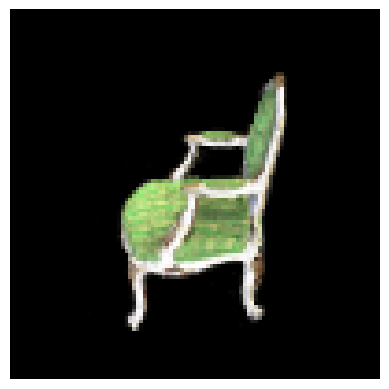

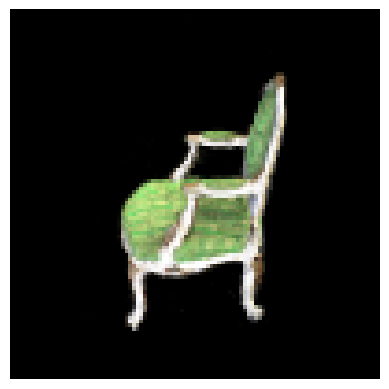

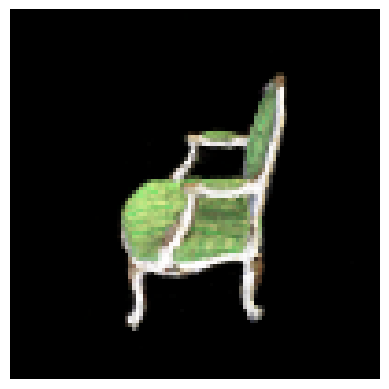

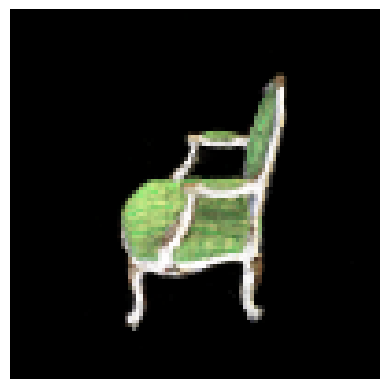

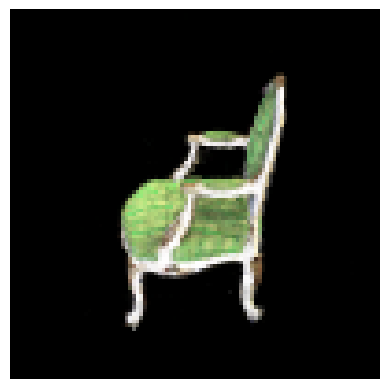

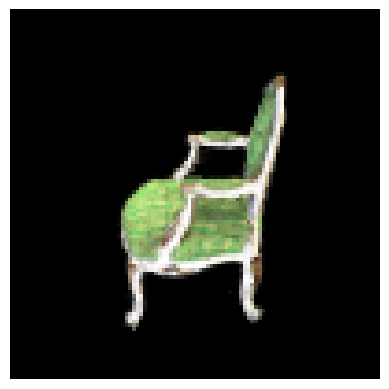

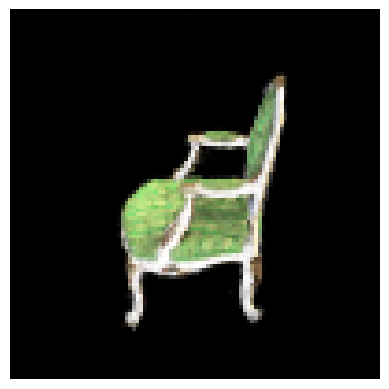

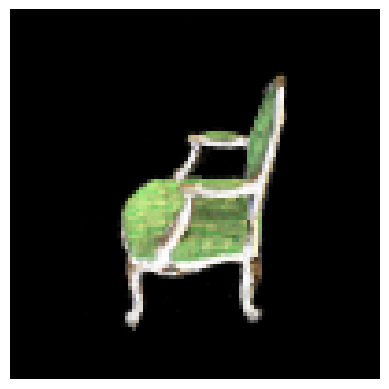

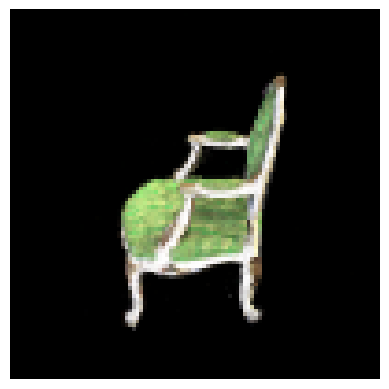

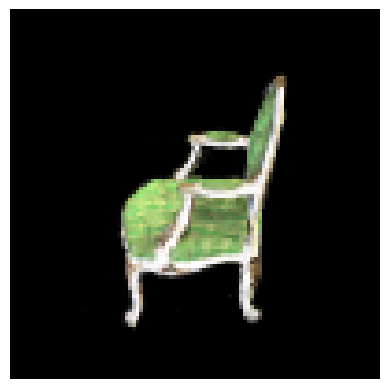

In [17]:
# Load generated turntable dataset
generated_dataset = AutoNeRF_Dataset(f"../generated_datasets/turntable_dataset_{dataset_name}.npz")
images_gen = torch.from_numpy(generated_dataset.images).to(device)

# Display first 10 generated images
for i in range(min(10, images_gen.shape[0])):
    show(images_gen[i].cpu())


## Plot the translation poses of the generated dataset and mark the center

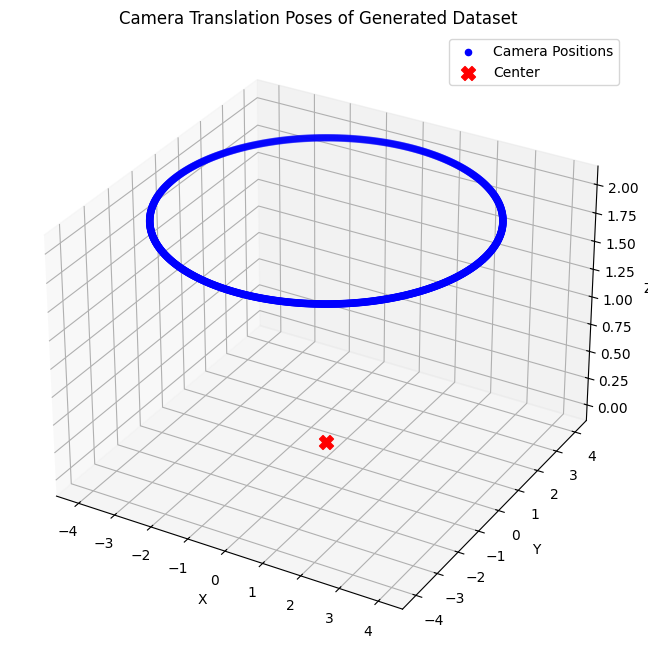

In [18]:
# Plot the translation poses of the generated dataset and mark the center
from mpl_toolkits.mplot3d import Axes3D

# Extract translations from generated poses
translations = torch.from_numpy(generated_dataset.poses[:, :3, 3]).cpu().numpy()

# Extract the center
center = torch.zeros(3).cpu().numpy()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the translations
ax.scatter(translations[:, 0], translations[:, 1], translations[:, 2], c='blue', label='Camera Positions')

# Mark the center
ax.scatter(center[0], center[1], center[2], c='red', s=100, label='Center', marker='X')

# Labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Camera Translation Poses of Generated Dataset')
ax.legend()
ax.grid(True)

plt.show()
